# QULIN — Exploratory Data Analysis

 Phase 3

Checks performed:
1. Day-of-week seasonality per item
2. Correlation between `prepared_qty` and `waste_qty`
3. Missing value check

Data source: `ml/data/processed/dataset.csv` (produced by `generate_sample_data.py`)

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

df = pd.read_csv("../data/processed/dataset.csv", parse_dates=["date"])
print(df.shape)
df.head()

(2265, 11)


,date,day_of_week,item,meal,prepared_qty,consumed_qty,waste_qty,waste_reason,stock_level,days_to_expiry,customer_count
0,2026-03-31,Tuesday,Bread,breakfast,72,38,138.0,plate_waste,63,157,77
1,2026-03-31,Tuesday,Bread,dinner,115,63,138.0,plate_waste,63,157,129
2,2026-03-31,Tuesday,Bread,lunch,144,92,138.0,plate_waste,63,157,192
3,2026-03-31,Tuesday,Chicken,breakfast,144,87,296.0,overproduction,140,156,244
4,2026-03-31,Tuesday,Chicken,dinner,230,148,296.0,overproduction,140,156,448


## 1. Missing Value Check

Confirms the export script's own check — should already be clean, this is the independent verification.

In [6]:
print(df.isnull().sum())
print("\nRow count:", len(df))
print("Date range:", df['date'].min(), "to", df['date'].max())

date              0
day_of_week       0
item              0
meal              0
prepared_qty      0
consumed_qty      0
waste_qty         0
waste_reason      0
stock_level       0
days_to_expiry    0
customer_count    0
dtype: int64

Row count: 2265
Date range: 2026-03-31 00:00:00 to 2026-08-28 00:00:00


## 2. Day-of-Week Seasonality

Grouping by `day_of_week`, comparing mean `prepared_qty` vs mean `consumed_qty` per item.

**Expected:** Rice should show `prepared_qty` staying roughly flat around 500 on Fridays
while `consumed_qty` fluctuates — this is the deliberately injected overproduction
pattern from `seed-db.js`, matching the source doc's Section 3 example.

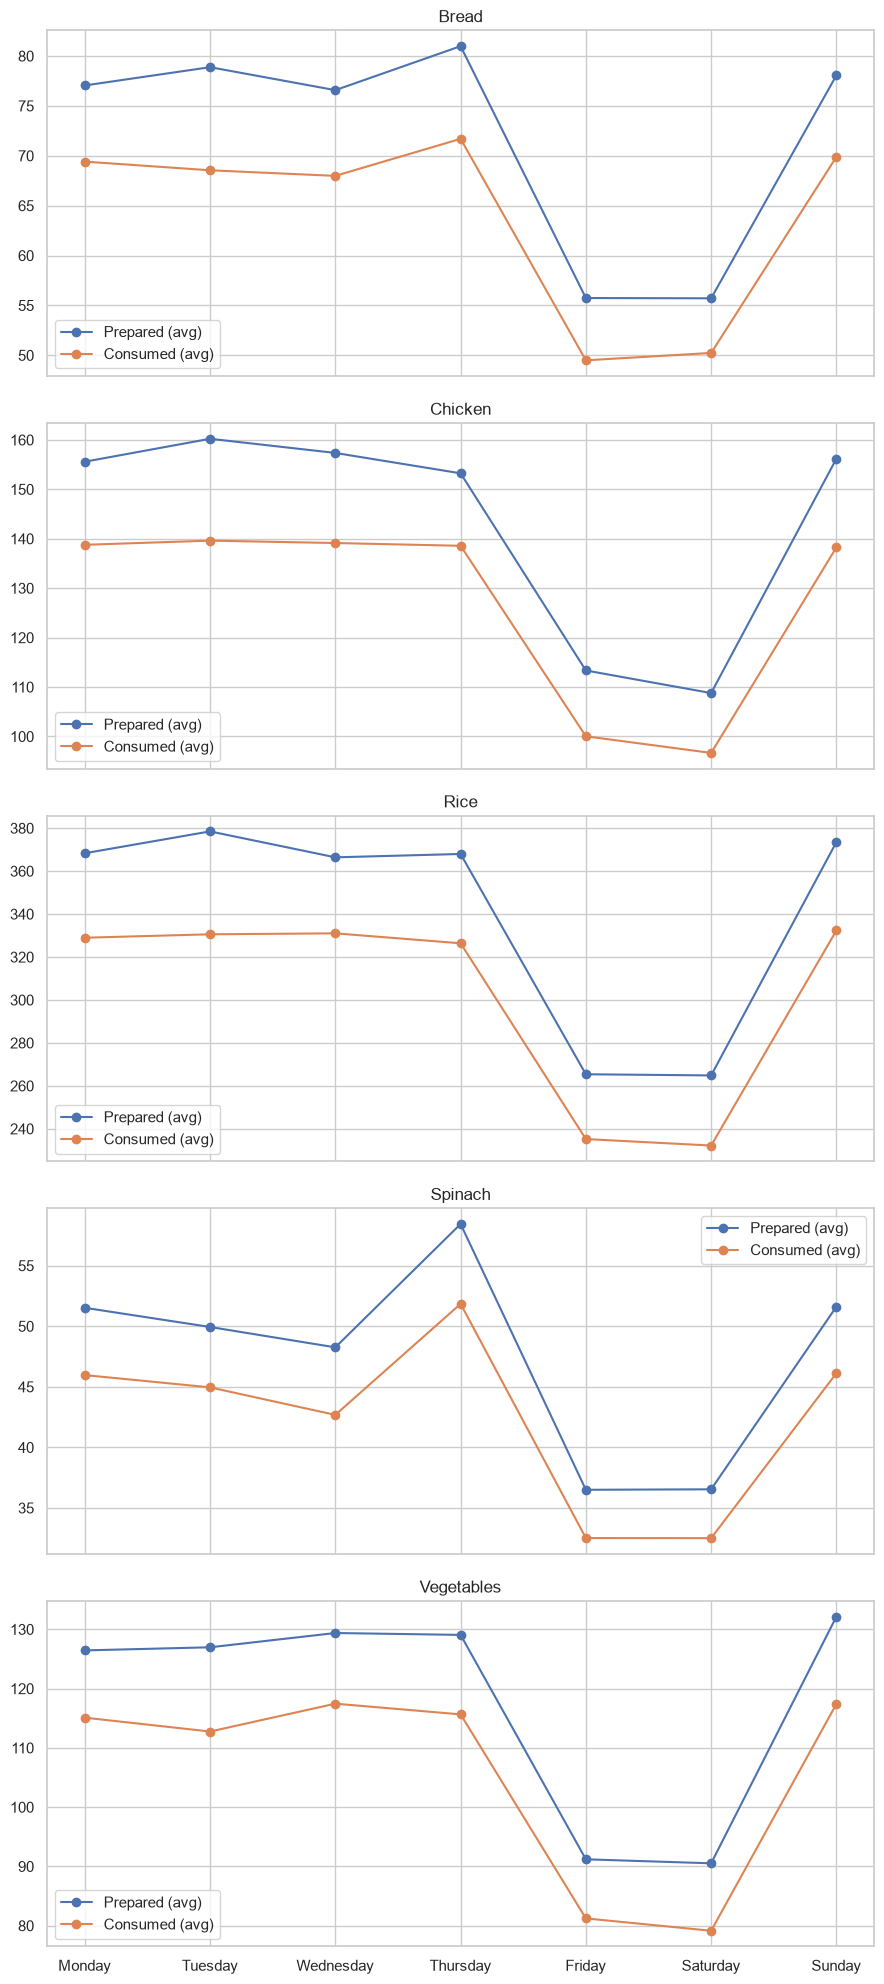

In [7]:
day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
df["day_of_week"] = pd.Categorical(df["day_of_week"], categories=day_order, ordered=True)

seasonality = (
    df.groupby(["item", "day_of_week"], observed=True)[["prepared_qty", "consumed_qty"]]
    .mean()
    .reset_index()
)

items = df["item"].unique()
fig, axes = plt.subplots(len(items), 1, figsize=(9, 4 * len(items)), sharex=True)

for ax, item in zip(axes, items):
    subset = seasonality[seasonality["item"] == item]
    ax.plot(subset["day_of_week"], subset["prepared_qty"], marker="o", label="Prepared (avg)")
    ax.plot(subset["day_of_week"], subset["consumed_qty"], marker="o", label="Consumed (avg)")
    ax.set_title(item)
    ax.legend()

plt.tight_layout()
plt.show()

## 3. Prepared vs Waste Correlation

Scatter of `prepared_qty` vs `waste_qty`, colored by item, with Friday points highlighted.

**Expected:** Rice should show the clearest positive slope specifically on Fridays
(constant high prep + variable demand = high waste), while other items show a
looser, more scattered relationship.

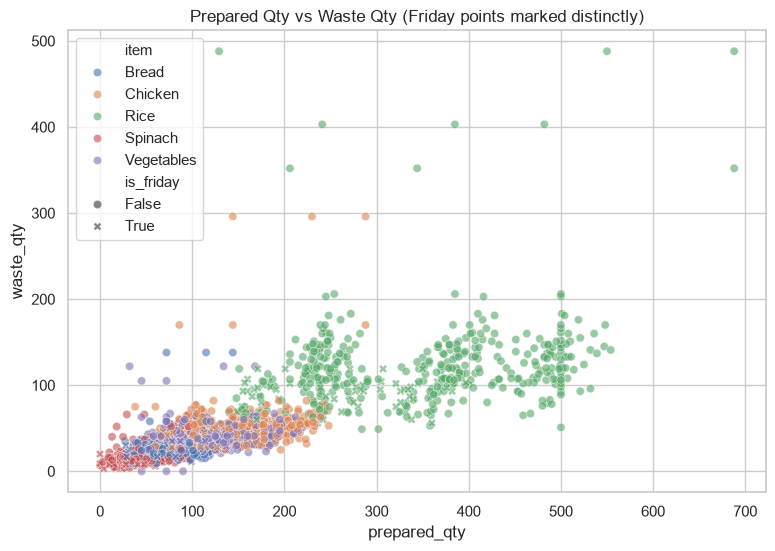

Correlation (prepared_qty vs waste_qty), Rice only, Friday only:
              prepared_qty  waste_qty
prepared_qty      1.000000   0.134782
waste_qty         0.134782   1.000000


In [8]:
df["is_friday"] = df["day_of_week"] == "Friday"

plt.figure(figsize=(9, 6))
sns.scatterplot(
    data=df,
    x="prepared_qty",
    y="waste_qty",
    hue="item",
    style="is_friday",
    alpha=0.6,
)
plt.title("Prepared Qty vs Waste Qty (Friday points marked distinctly)")
plt.show()

print("Correlation (prepared_qty vs waste_qty), Rice only, Friday only:")
rice_friday = df[(df["item"] == "Rice") & (df["is_friday"])]
print(rice_friday[["prepared_qty", "waste_qty"]].corr())

## Notes / Findings

_(Fill in after running — e.g. confirm Friday-rice overproduction pattern is visible,
note any other items worth flagging, note whether `rolling_7day_avg_consumption`
looks like it will be a useful engineered feature for Phase 5.)_